# 기말고사 과제
- 학번: 20241773
- 이름: 후슬렝(BAASANDORJ KHUSLEN)




In [8]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

In [9]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# ============================================================
# 1. 원본 데이터 정의 및 가상 데이터 증강 (Data Augmentation)
# ============================================================
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

d_data_orig = np.column_stack((dach_length, dach_height))
j_data_orig = np.column_stack((jin_length, jin_height))

def augment_data(orig_data, target_count=100, noise_level=6.5, random_state=42):
    np.random.seed(random_state)
    augmented = []
    for _ in range(target_count):
        idx = np.random.choice(len(orig_data))
        noise = np.random.normal(0, noise_level, size=2)
        augmented.append(orig_data[idx] + noise)
    return np.array(augmented)

# 닥스훈트(0) 및 진돗개(1) 데이터 생성
X_dach = augment_data(d_data_orig, target_count=100, noise_level=6.5, random_state=42)
y_dach = np.zeros(len(X_dach))

X_jin = augment_data(j_data_orig, target_count=100, noise_level=6.5, random_state=100)
y_jin = np.ones(len(X_jin))

# =====================================================
# 2. 독립 변수(X) 및 종속 변수(y) 지정
# =====================================================
X = np.concatenate((X_dach, X_jin))
y = np.concatenate((y_dach, y_jin))

# =====================================================
# 3. 학습 데이터(Train) 및 테스트 데이터(Test) 분리
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================================
# 4. 파이프라인(Pipeline)을 이용한 3가지 모델 생성
# ======================================================
model1 = Pipeline([('scaler', StandardScaler()), ('regressor', LogisticRegression(C=1.0, penalty='l2', random_state=42))])
model2 = Pipeline([('scaler', StandardScaler()), ('regressor', KNeighborsClassifier(n_neighbors=5, weights='distance'))])
model3 = Pipeline([('scaler', StandardScaler()), ('regressor', SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42))])

# ======================================================
# 5. 모델 학습 (Fit)
# ======================================================
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

# ======================================================
# 6. 학습된 모델 파일 저장 (.pkl)
# ======================================================
joblib.dump(model1, 'model1_logistic.pkl')
joblib.dump(model2, 'model2_knn.pkl')
joblib.dump(model3, 'model3_svm.pkl')

print("✅ [성공] 모델 학습 및 .pkl 파일 저장이 완료되었습니다!")
print(f"훈련 데이터 크기: {X_train.shape}, 테스트 데이터 크기: {X_test.shape}")

✅ [성공] 모델 학습 및 .pkl 파일 저장이 완료되었습니다!
훈련 데이터 크기: (160, 2), 테스트 데이터 크기: (40, 2)


# 결과 캡처 사진입니다.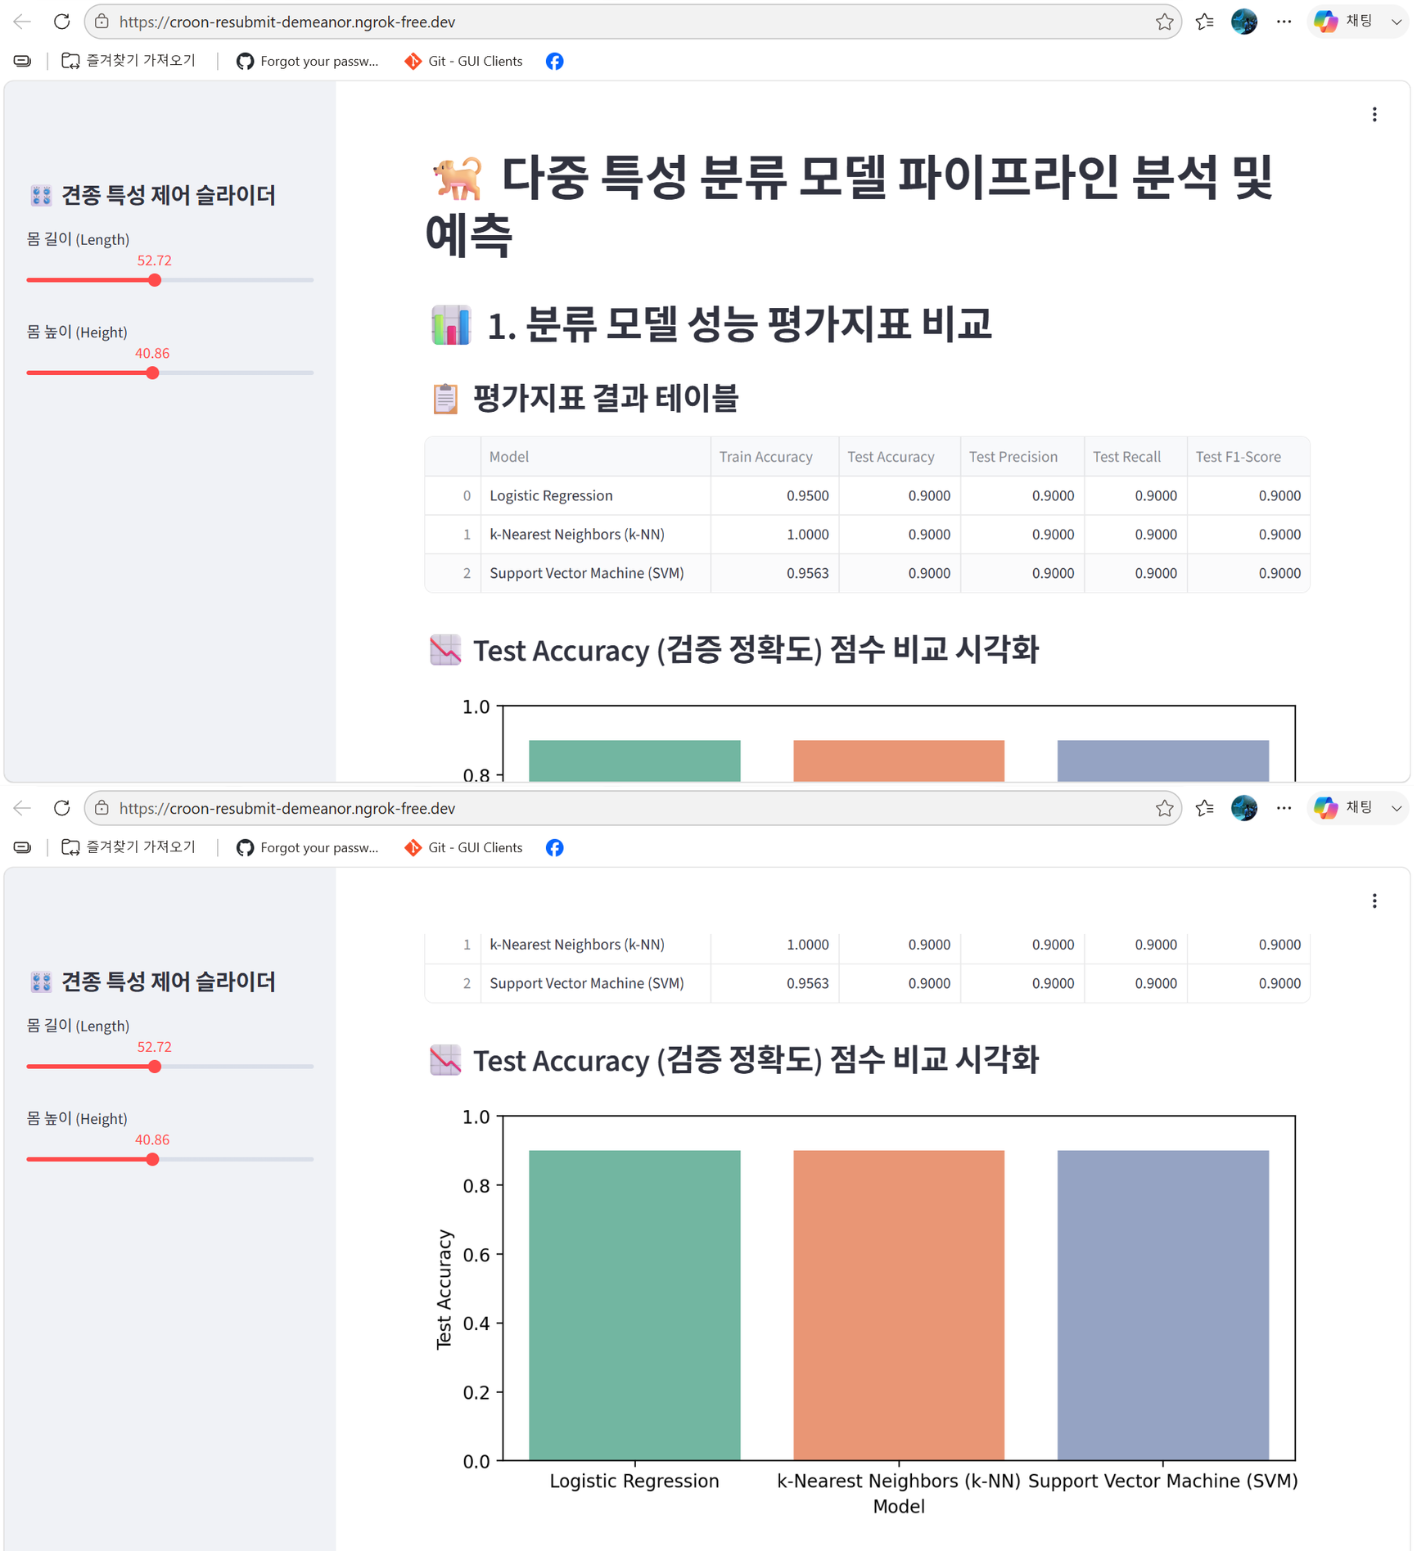

In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 웹 페이지 레이아웃 및 제목 설정 (교수님 요구사항 반영)
st.set_page_config(page_title="견종 분류 예측 대시보드", layout="wide")
st.title("🐕 다중 특성 분류 모델 파이프라인 분석 및 예측")

# ============================================================
# 1. 데이터 준비 및 증강 (이전 코드와 완전히 동일한 데이터셋 구성)
# ============================================================
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

d_data_orig = np.column_stack((dach_length, dach_height))
j_data_orig = np.column_stack((jin_length, jin_height))

def augment_data(orig_data, target_count=100, noise_level=6.5, random_state=42):
    np.random.seed(random_state)
    augmented = []
    for _ in range(target_count):
        idx = np.random.choice(len(orig_data))
        noise = np.random.normal(0, noise_level, size=2)
        augmented.append(orig_data[idx] + noise)
    return np.array(augmented)

# 닥스훈트(0) 및 진돗개(1) 증강 데이터 합치기
X_dach = augment_data(d_data_orig, target_count=100, noise_level=6.5, random_state=42)
y_dach = np.zeros(len(X_dach))

X_jin = augment_data(j_data_orig, target_count=100, noise_level=6.5, random_state=100)
y_jin = np.ones(len(X_jin))

X = np.concatenate((X_dach, X_jin))
y = np.concatenate((y_dach, y_jin))

# 데이터 프레임 형태로 변환 (대시보드 슬라이더 범위 추출용)
df_augmented = pd.DataFrame(X, columns=['Length', 'Height'])
df_augmented['Target'] = y

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 학습된 모델 객체 로드
@st.cache_resource
def load_models():
    return (
        joblib.load('model1_logistic.pkl'),
        joblib.load('model2_knn.pkl'),
        joblib.load('model3_svm.pkl')
    )

model1, model2, model3 = load_models()

# ============================================================
# [조건 3] 모델들의 성능을 비교하는 테이블 및 그래프 시각화
# ============================================================
st.header("📊 1. 분류 모델 성능 평가지표 비교")
models_dict = {
    'Logistic Regression': model1,
    'k-Nearest Neighbors (k-NN)': model2,
    'Support Vector Machine (SVM)': model3
}
performance_data = []

for name, model in models_dict.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    performance_data.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Test Precision': precision_score(y_test, test_pred),
        'Test Recall': recall_score(y_test, test_pred),
        'Test F1-Score': f1_score(y_test, test_pred)
    })

df_res = pd.DataFrame(performance_data)
st.subheader("📋 평가지표 결과 테이블")
st.dataframe(df_res.style.format({
    'Train Accuracy': '{:.4f}', 'Test Accuracy': '{:.4f}',
    'Test Precision': '{:.4f}', 'Test Recall': '{:.4f}', 'Test F1-Score': '{:.4f}'
}))

st.subheader("📉 Test Accuracy (검증 정확도) 점수 비교 시각화")
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x='Model', y='Test Accuracy', data=df_res, ax=ax, palette='Set2')
ax.set_ylim(0.0, 1.0) # 정확도는 0부터 1 사이로 고정
st.pyplot(fig)

st.markdown("---")

# ============================================================
# [조건 4] 사이드바 슬라이더를 통한 실시간 견종 분류 예측
# ============================================================
st.header("🔮 2. 실시간 견종 분류 예측")
st.sidebar.header("🎛️ 견종 특성 제어 슬라이더")

# 데이터 기반 동적 슬라이더 설정
input_length = st.sidebar.slider("몸 길이 (Length)", float(df_augmented['Length'].min()), float(df_augmented['Length'].max()), float(df_augmented['Length'].mean()))
input_height = st.sidebar.slider("몸 높이 (Height)", float(df_augmented['Height'].min()), float(df_augmented['Height'].max()), float(df_augmented['Height'].mean()))

selected_model_name = st.selectbox("분류 알고리즘 모델 선택:", ["Logistic Regression", "k-NN", "SVM"])
chosen_model = model1 if selected_model_name == "Logistic Regression" else (model2 if selected_model_name == "k-NN" else model3)

# 유저 입력값을 모델 예측용 2차원 배열로 변환
user_input = np.array([[input_length, input_height]])
prediction = chosen_model.predict(user_input)[0]
pred_proba = chosen_model.predict_proba(user_input)[0] # 확률 값 가져오기

# 예측 결과 매핑
dog_classes = {0: '닥스훈트 (Dachshund)', 1: '진돗개 (Jindo Dog)'}
result_text = dog_classes[prediction]
probability = pred_proba[int(prediction)] * 100

st.write(f"**선택된 모델:** {selected_model_name} Pipeline")
st.markdown(f"""
<div style="background-color:#f0f2f6; padding:20px; border-radius:10px; text-align:center;">
    <h3 style="margin:0; color:#333;">🎯 예측된 견종 결과 (Classification Result)</h3>
    <h1 style="margin:10px 0 0 0; color:#ff4b4b; font-size:42px;">{result_text}</h1>
    <h4 style="margin:10px 0 0 0; color:#555;">예측 신뢰도(확률): {probability:.2f}%</h4>
</div>
""", unsafe_allow_html=True)

Overwriting app.py


# 결과 캡처 사진입니다.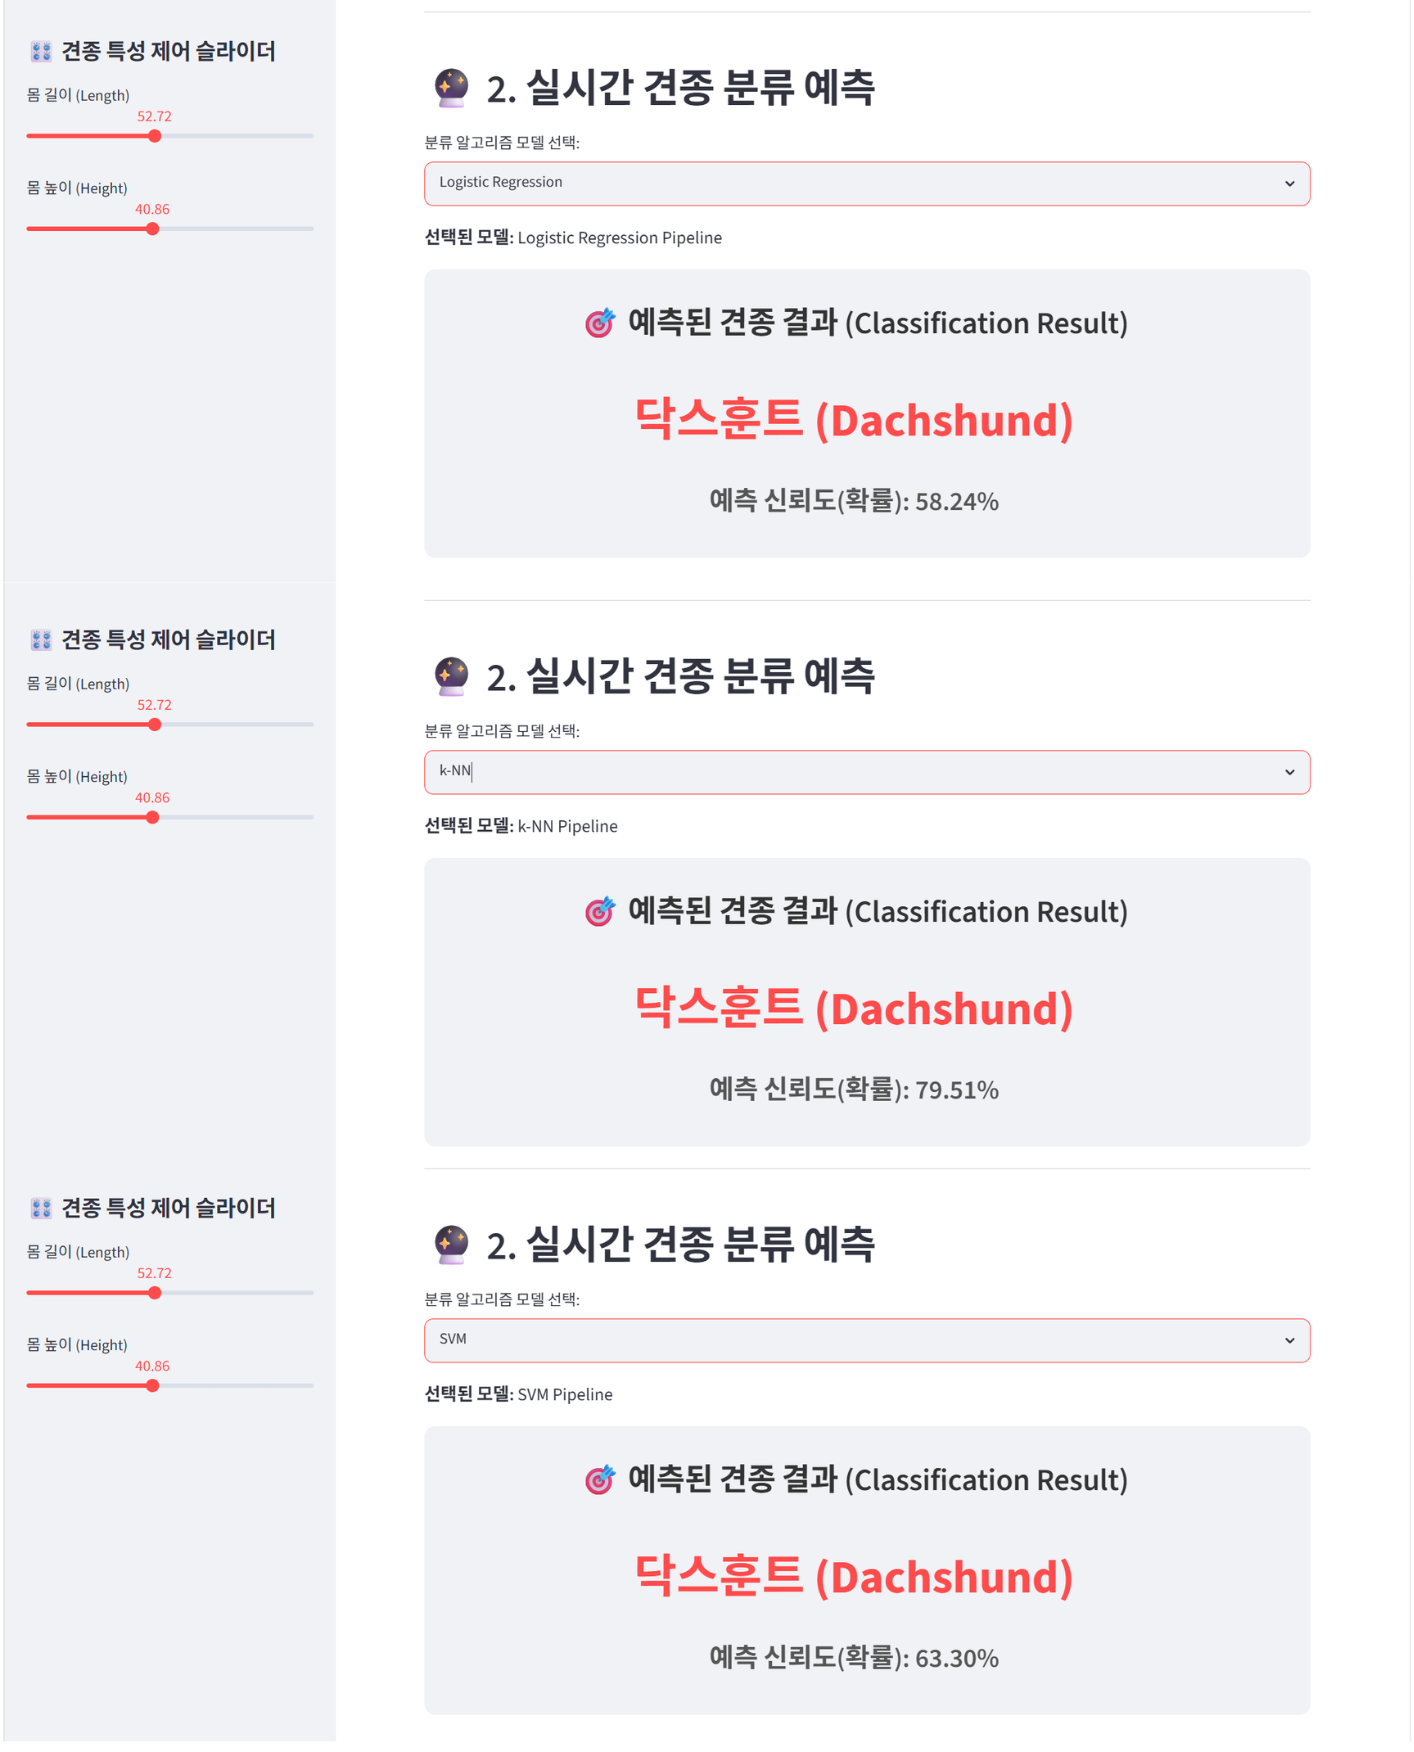

In [11]:
# 기존 프로세스 정리 및 필수 라이브러리 설치
!pkill ngrok
!pip install pyngrok -q

NGROK_TOKEN = "3Dw1w8oWk8SgHSMHv0xIAST6fuA_3FNxc6gahZg8TucNZnruv"
!ngrok config add-authtoken {NGROK_TOKEN}

import os
from pyngrok import ngrok

# Streamlit 구동
os.system("streamlit run app.py --server.port 8501 &")

try:
    ngrok.kill()
except:
    pass

# 터널링 연결
public_url = ngrok.connect(8501)

print("\n" + "="*70)
print("🌍 Streamlit 서비스가 성공적으로 온라인에 배포되었습니다!")
print(f"🔗 아래의 링크를 클릭하여 대시보드에 접속하세요:\n{public_url}")
print("="*70)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml

🌍 Streamlit 서비스가 성공적으로 온라인에 배포되었습니다!
🔗 아래의 링크를 클릭하여 대시보드에 접속하세요:
NgrokTunnel: "https://croon-resubmit-demeanor.ngrok-free.dev" -> "http://localhost:8501"
